In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
import pandas
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
test =  pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

# Data Exploration

In [4]:
train


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [6]:
train.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [7]:
train.nunique()

id                        517754
road_type                      3
num_lanes                      4
curvature                    261
speed_limit                    5
lighting                       3
weather                        3
road_signs_present             2
public_road                    2
time_of_day                    3
holiday                        2
school_season                  2
num_reported_accidents         8
accident_risk                 98
dtype: int64

In [8]:
train.describe(include=['object', 'bool'])

,road_type,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season
count,517754,517754,517754,517754,517754,517754,517754,517754
unique,3,3,3,2,2,3,2,2
top,highway,dim,foggy,False,True,morning,True,False
freq,173672,183826,181463,259289,260045,173410,260688,260164


In [9]:
# get unique values for categroical data
threshold = 10

for column in train.columns:
    num_unique_values = train[column].nunique()

    if num_unique_values < threshold:
        print(f"-- {column}")
        print(sorted(train[column].unique()))

-- road_type
['highway', 'rural', 'urban']
-- num_lanes
[1, 2, 3, 4]
-- speed_limit
[25, 35, 45, 60, 70]
-- lighting
['daylight', 'dim', 'night']
-- weather
['clear', 'foggy', 'rainy']
-- road_signs_present
[False, True]
-- public_road
[False, True]
-- time_of_day
['afternoon', 'evening', 'morning']
-- holiday
[False, True]
-- school_season
[False, True]
-- num_reported_accidents
[0, 1, 2, 3, 4, 5, 6, 7]


Text(0.5, 0, 'accident risk')

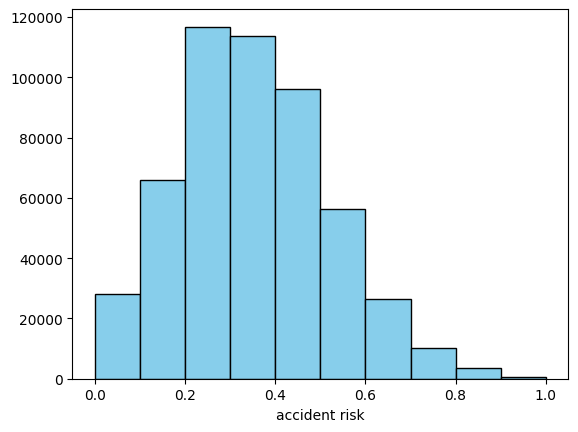

In [10]:
plt.hist(train['accident_risk'], bins = 10, color = 'skyblue', edgecolor= 'black')
plt.xlabel("accident risk")

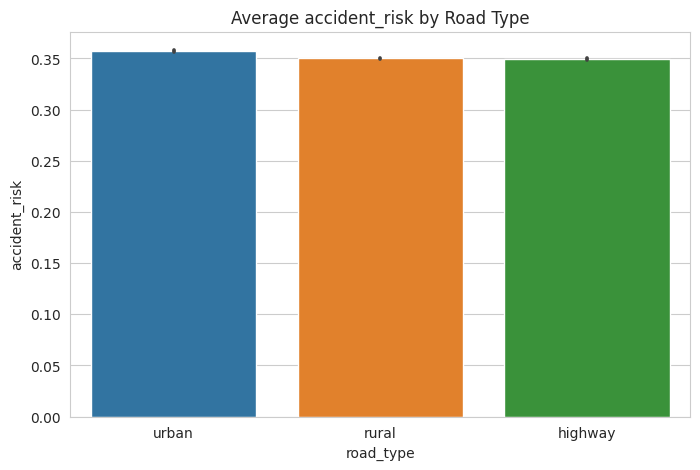

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


target_column = 'accident_risk' 

sns.set_style('whitegrid')


plt.figure(figsize=(8, 5)) 
sns.barplot(x='road_type', y=target_column, data=train)
plt.title(f'Average {target_column} by Road Type')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


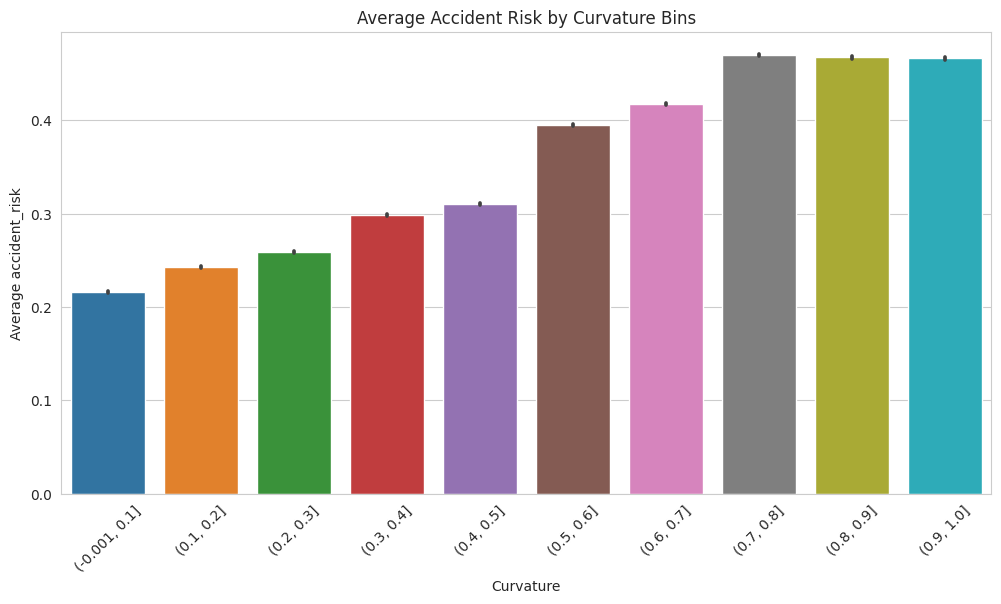

In [12]:
train['curvature_bin'] = pd.cut(train['curvature'], bins=10)

# 2. Create a bar plot of the average risk for each bin
plt.figure(figsize=(12, 6))
sns.barplot(x='curvature_bin', y=target_column, data=train)
plt.title('Average Accident Risk by Curvature Bins')
plt.xlabel('Curvature')
plt.ylabel(f'Average {target_column}')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.show()

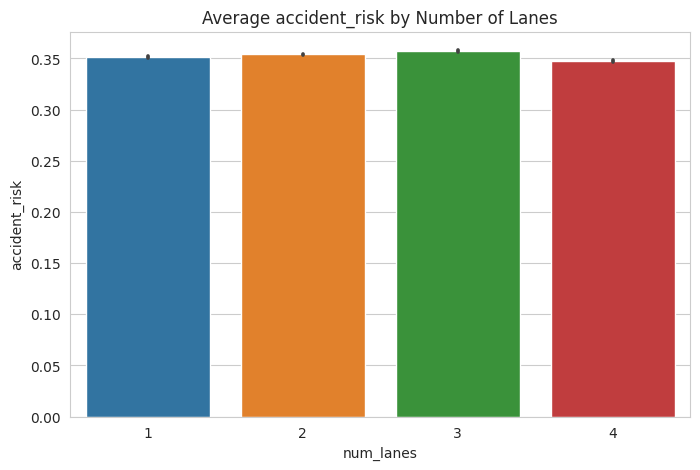

In [13]:

plt.figure(figsize=(8, 5)) 
sns.barplot(x='num_lanes', y=target_column, data=train)
plt.title(f'Average {target_column} by Number of Lanes')
plt.show() 

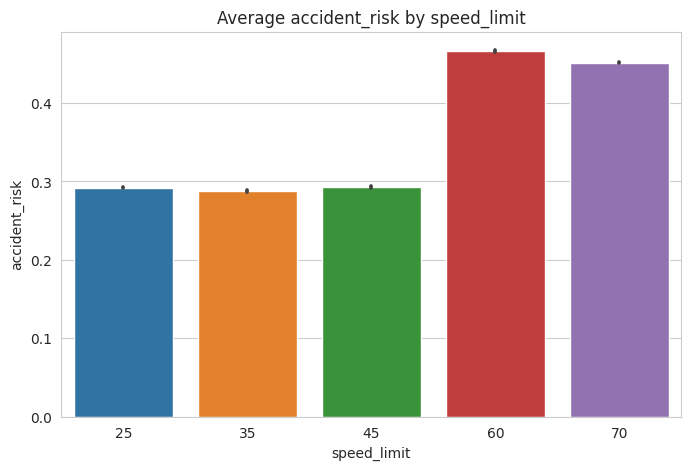

In [14]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='speed_limit', y=target_column, data=train)
plt.title(f'Average {target_column} by speed_limit')
plt.show() 

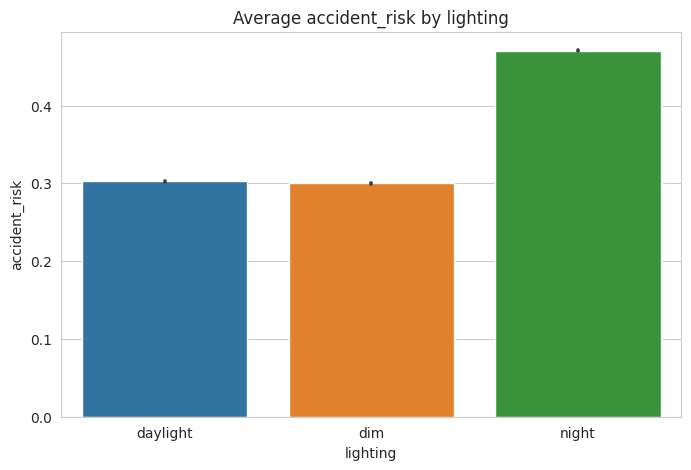

In [15]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='lighting', y=target_column, data=train)
plt.title(f'Average {target_column} by lighting')
plt.show()

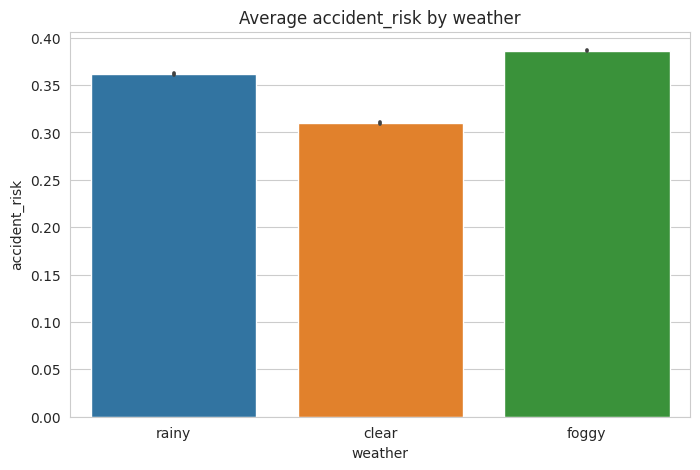

In [16]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='weather', y=target_column, data=train)
plt.title(f'Average {target_column} by weather')
plt.show()

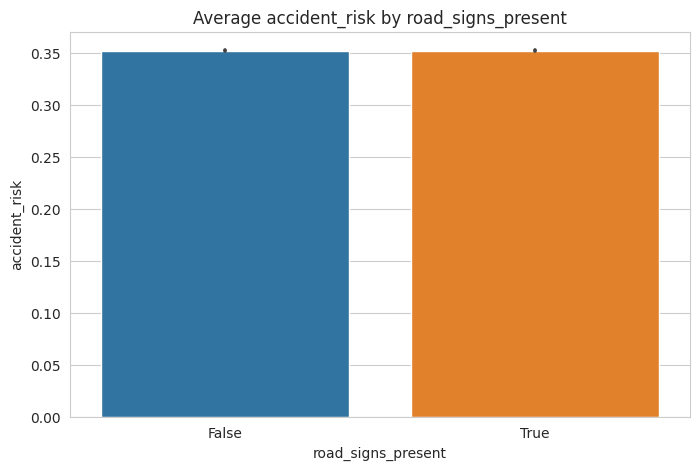

In [17]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='road_signs_present', y=target_column, data=train)
plt.title(f'Average {target_column} by road_signs_present')
plt.show()

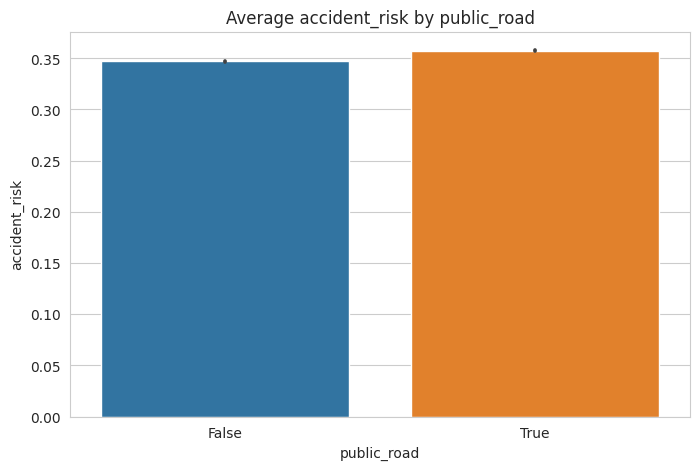

In [18]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='public_road', y=target_column, data=train)
plt.title(f'Average {target_column} by public_road')
plt.show()

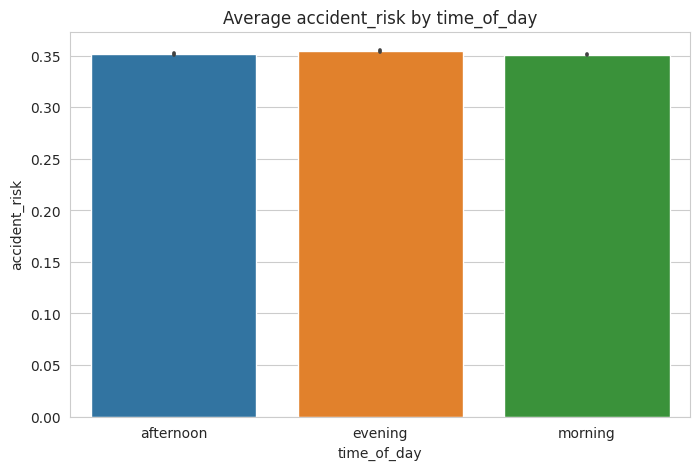

In [19]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='time_of_day', y=target_column, data=train)
plt.title(f'Average {target_column} by time_of_day')
plt.show()

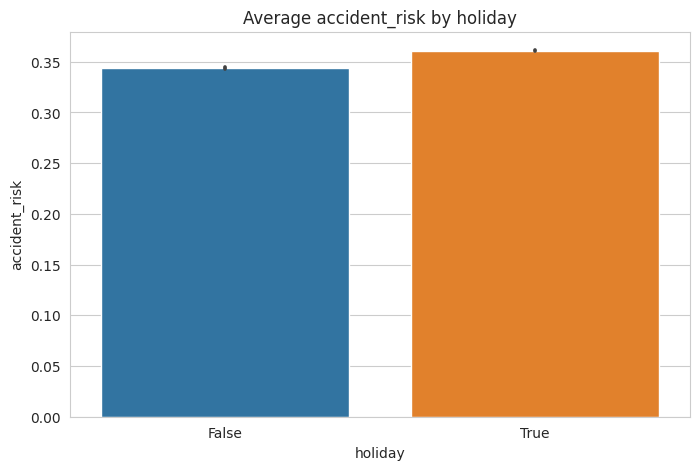

In [20]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='holiday', y=target_column, data=train)
plt.title(f'Average {target_column} by holiday')
plt.show()

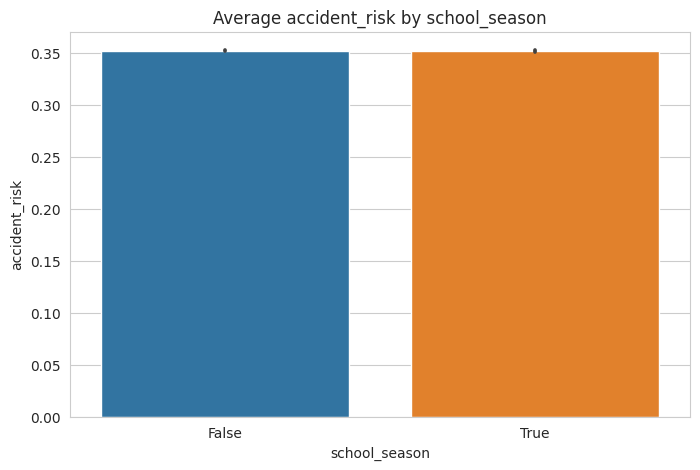

In [21]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='school_season', y=target_column, data=train)
plt.title(f'Average {target_column} by school_season')
plt.show()

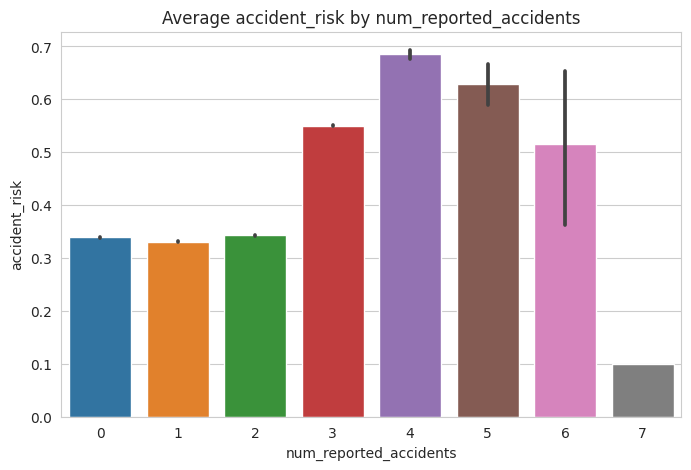

In [22]:
plt.figure(figsize=(8, 5)) 
sns.barplot(x='num_reported_accidents', y=target_column, data=train)
plt.title(f'Average {target_column} by num_reported_accidents')
plt.show()

# Encoding


In [23]:
time_of_day_mapping = {'morning' :1, 'afternoon' : 2, 'evening' : 3}
lighting_mapping = {'daylight' : 1, 'dim' : 2, 'night': 3}

In [24]:
train['time_of_day_encoded'] = train['time_of_day'].map(time_of_day_mapping)
train['lighting_encoded'] = train['lighting'].map(lighting_mapping)

In [25]:
nominal_features = ['road_type', 'weather']
train = pd.get_dummies(train, columns= nominal_features, drop_first= True)

In [26]:
train

,id,num_lanes,curvature,speed_limit,lighting,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,curvature_bin,time_of_day_encoded,lighting_encoded,road_type_rural,road_type_urban,weather_foggy,weather_rainy
0,0,2,0.06,35,daylight,False,True,afternoon,False,True,1,0.13,"(-0.001, 0.1]",2,1,False,True,False,True
1,1,4,0.99,35,daylight,True,False,evening,True,True,0,0.35,"(0.9, 1.0]",3,1,False,True,False,False
2,2,4,0.63,70,dim,False,True,morning,True,False,2,0.30,"(0.6, 0.7]",1,2,True,False,False,False
3,3,4,0.07,35,dim,True,True,morning,False,False,1,0.21,"(-0.001, 0.1]",1,2,False,False,False,True
4,4,1,0.58,60,daylight,False,False,evening,True,False,1,0.56,"(0.5, 0.6]",3,1,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,4,0.10,70,daylight,True,True,afternoon,False,False,2,0.32,"(-0.001, 0.1]",2,1,False,False,True,False
517750,517750,4,0.47,35,daylight,True,True,morning,False,False,1,0.26,"(0.4, 0.5]",1,1,True,False,False,True
517751,517751,4,0.62,25,daylight,False,False,afternoon,False,True,0,0.19,"(0.6, 0.7]",2,1,False,True,True,False
517752,517752,3,0.63,25,night,True,False,afternoon,True,True,3,0.51,"(0.6, 0.7]",2,3,False,False,False,False


In [27]:
train_data_encoded = train.drop(['lighting','time_of_day', 'curvature_bin' ], axis = 'columns')

In [28]:
train_data_encoded

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,time_of_day_encoded,lighting_encoded,road_type_rural,road_type_urban,weather_foggy,weather_rainy
0,0,2,0.06,35,False,True,False,True,1,0.13,2,1,False,True,False,True
1,1,4,0.99,35,True,False,True,True,0,0.35,3,1,False,True,False,False
2,2,4,0.63,70,False,True,True,False,2,0.30,1,2,True,False,False,False
3,3,4,0.07,35,True,True,False,False,1,0.21,1,2,False,False,False,True
4,4,1,0.58,60,False,False,True,False,1,0.56,3,1,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,4,0.10,70,True,True,False,False,2,0.32,2,1,False,False,True,False
517750,517750,4,0.47,35,True,True,False,False,1,0.26,1,1,True,False,False,True
517751,517751,4,0.62,25,False,False,False,True,0,0.19,2,1,False,True,True,False
517752,517752,3,0.63,25,True,False,True,True,3,0.51,2,3,False,False,False,False


<function matplotlib.pyplot.show(close=None, block=None)>

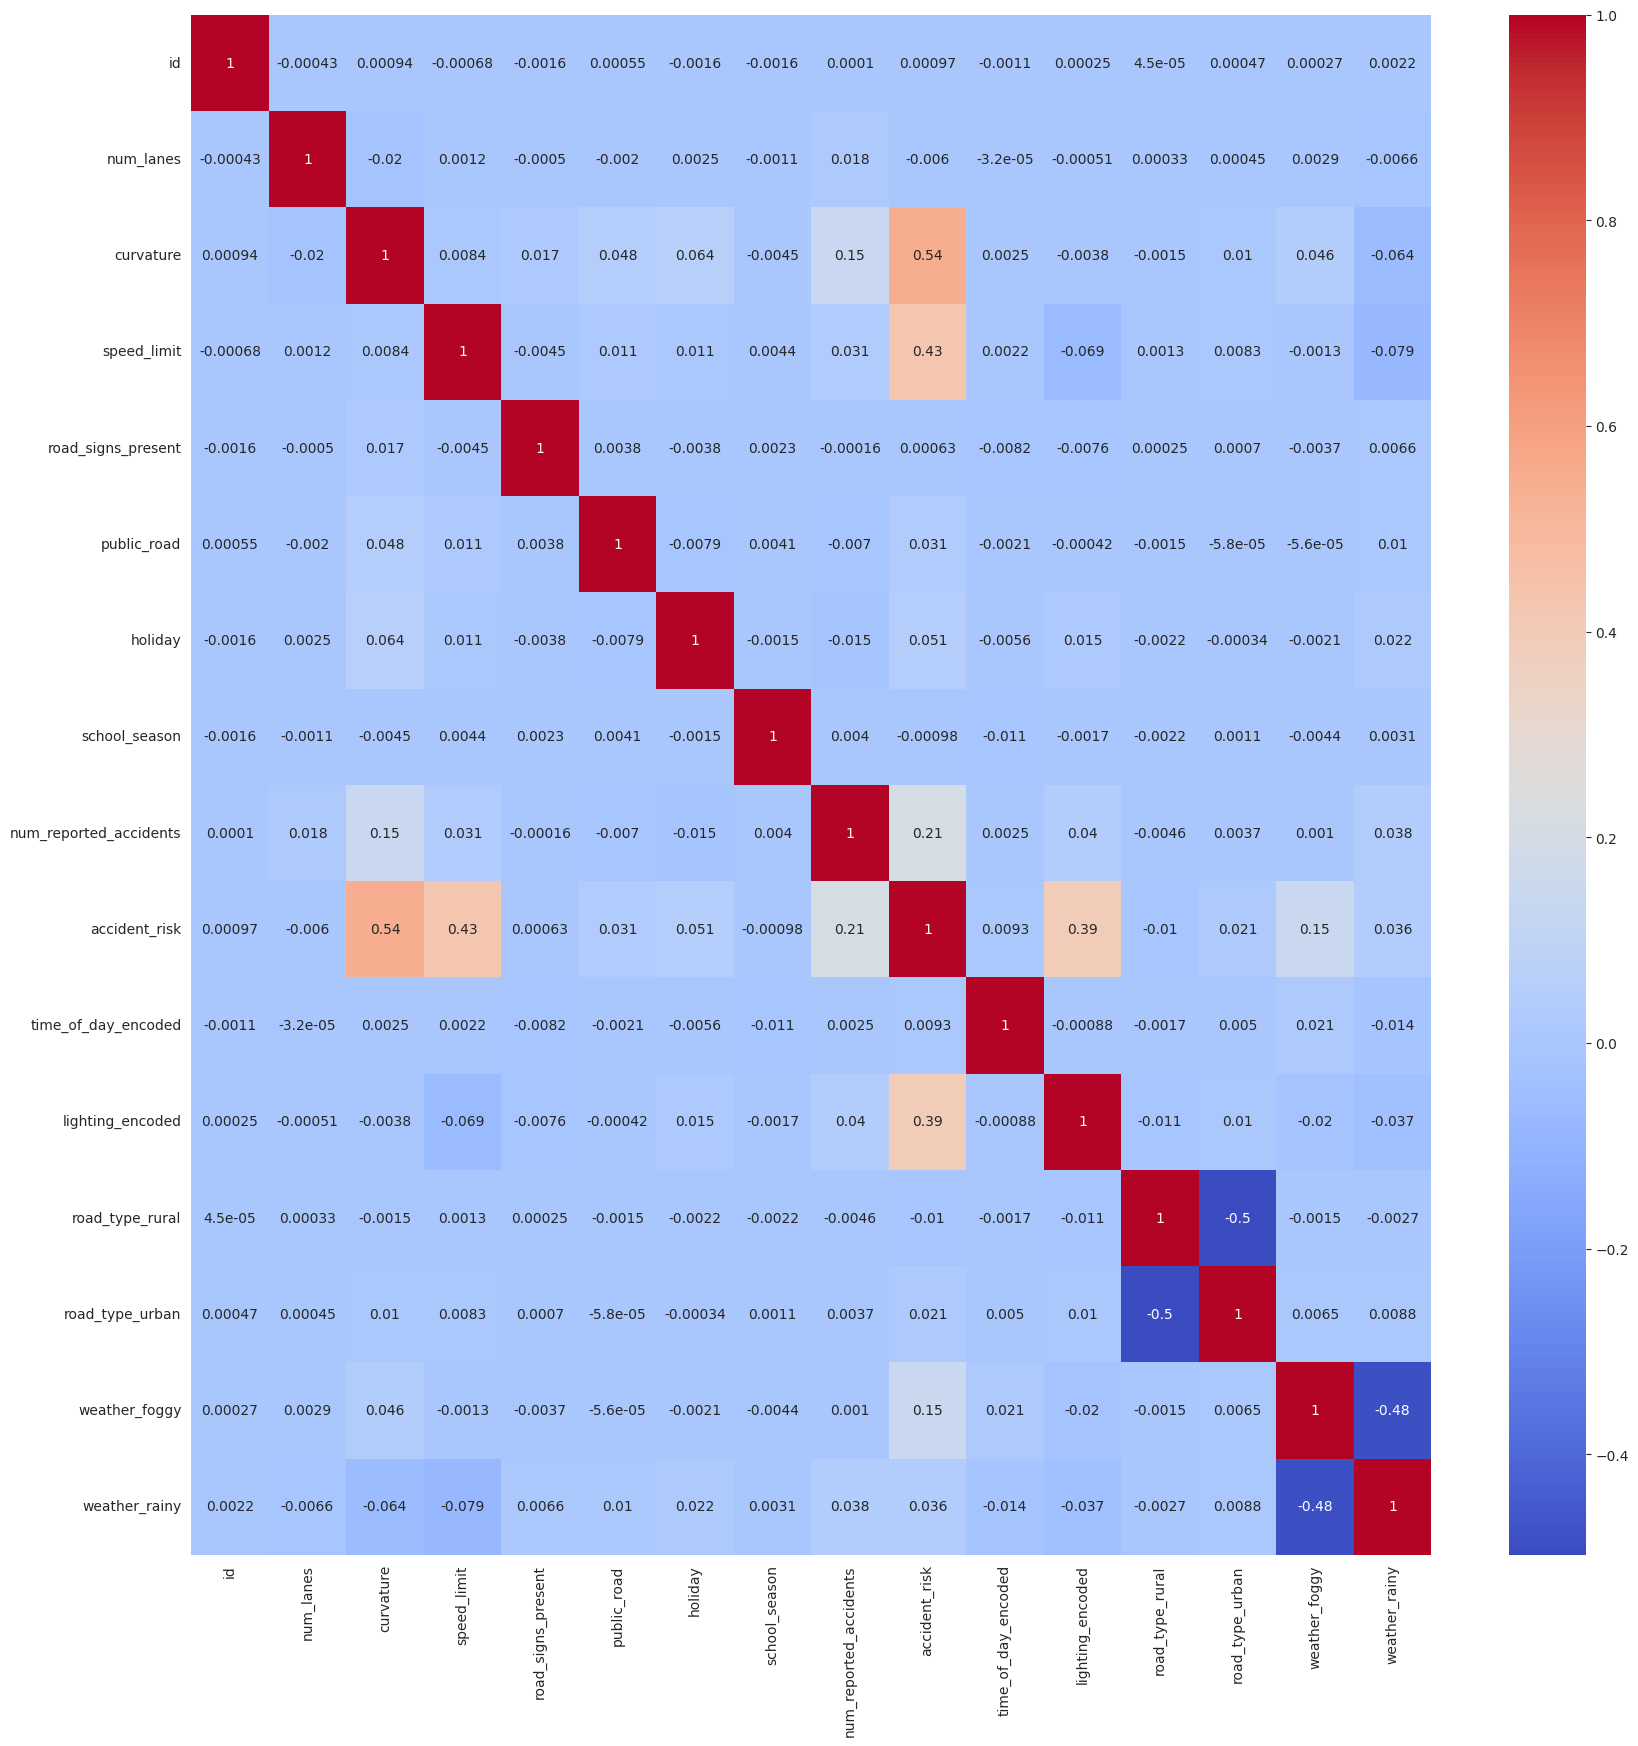

In [29]:
corr_matrix=train_data_encoded.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm')
plt.show

In [30]:
target_correlations = corr_matrix['accident_risk'].drop('accident_risk') # Drop its correlation with itself

# Sort the values to see the most correlated features at the top
sorted_correlations = target_correlations.sort_values(ascending=False)
sorted_correlations

curvature                 0.543946
speed_limit               0.430898
lighting_encoded          0.393860
num_reported_accidents    0.213891
weather_foggy             0.149758
holiday                   0.051129
weather_rainy             0.036137
public_road               0.031032
road_type_urban           0.021463
time_of_day_encoded       0.009259
id                        0.000969
road_signs_present        0.000629
school_season            -0.000977
num_lanes                -0.006003
road_type_rural          -0.010121
Name: accident_risk, dtype: float64

In [31]:
target_column = 'accident_risk'
final_train_data = train_data_encoded.drop(columns=[
    'id', target_column 
])

In [32]:
X = final_train_data
y = train_data_encoded[target_column] # The target variable remains the same



In [33]:
X.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,time_of_day_encoded,lighting_encoded,road_type_rural,road_type_urban,weather_foggy,weather_rainy
0,2,0.06,35,False,True,False,True,1,2,1,False,True,False,True
1,4,0.99,35,True,False,True,True,0,3,1,False,True,False,False
2,4,0.63,70,False,True,True,False,2,1,2,True,False,False,False
3,4,0.07,35,True,True,False,False,1,1,2,False,False,False,True
4,1,0.58,60,False,False,True,False,1,3,1,True,False,True,False


In [34]:
y.head()

0    0.13
1    0.35
2    0.30
3    0.21
4    0.56
Name: accident_risk, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, stratify = y)

In [37]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (414203, 14)
Shape of X_val: (103551, 14)
Shape of y_train: (414203,)
Shape of y_val: (103551,)


In [38]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete!")

Training the Random Forest model...
Model training complete!


In [39]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
predictions = model.predict(X_val)
mae = mean_absolute_error(y_val, predictions)



rmse= mean_squared_error(y_val, predictions, squared=False)

In [40]:
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 0.05956396156631226
MAE: 0.04616713409442529


In [41]:

# 1. Calculate the mean value of the target from the TRAINING set
mean_prediction = y_train.mean()

print(f"The mean accident risk from the training data is: {mean_prediction:.6f}")

# 2. Create an array of predictions, where every prediction is the mean
# The array must be the same size as our validation set (y_val)
baseline_predictions = np.full(shape=y_val.shape, fill_value=mean_prediction)

# 3. Evaluate this baseline model using the same metrics
baseline_rmse = mean_squared_error(y_val, baseline_predictions, squared=False)
baseline_mae = mean_absolute_error(y_val, baseline_predictions)


print("\n--- Baseline Model (Predicting the Mean) ---")
print(f"Baseline RMSE: {baseline_rmse:.6f}")
print(f"Baseline MAE:  {baseline_mae:.6f}")

The mean accident risk from the training data is: 0.352375

--- Baseline Model (Predicting the Mean) ---
Baseline RMSE: 0.166433
Baseline MAE:  0.132894


In [42]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the grid of hyperparameters to search
# We'll choose a range of values for each.
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None], # None means the trees grow as deep as they can
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0] # '1.0' means consider all features
}

# 2. Create the RandomizedSearchCV object
# We use our original, untuned model as the base estimator.
# n_iter=10 means it will try 10 different random combinations.
# cv=5 means it will use 5-fold cross-validation.
# scoring='neg_mean_squared_error' is used because search tools try to MAXIMIZE a score,
# so we use the negative of MSE (making it bigger is better).
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2, # This will print progress updates
    random_state=42
)

# 3. Fit the search to your training data
print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)
print("Search complete!")

# 4. Get the best parameters
print("\nBest hyperparameters found:")
print(random_search.best_params_)

# 5. Get the best model
best_model = random_search.best_estimator_

# 6. Now, let's evaluate our new, tuned model on the validation set
new_predictions = best_model.predict(X_val)
new_rmse = mean_squared_error(y_val, new_predictions, squared=False)
new_mae = mean_absolute_error(y_val, new_predictions)

print("\n--- Comparison ---")
print(f"Original Model RMSE: {rmse:.6f}")
print(f"Tuned Model RMSE:    {new_rmse:.6f}")
print("\n")
print(f"Original Model MAE: {mae:.6f}")
print(f"Tuned Model MAE:    {new_mae:.6f}")

Starting hyperparameter search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, n_estimators=200; total time=  28.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, n_estimators=200; total time=  27.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, n_estimators=200; total time=  27.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, n_estimators=200; total time=  27.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, n_estimators=200; total time=  27.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, n_estimators=500; total time=  43.5s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, n_estimators=500; total time=  43.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, n_estimators=500; total time=  43.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, n_estimators=500; total time=  43.6s
[CV]

In [43]:
# --- Step 1: Preprocess the Test Data ---
# We must apply the IDENTICAL transformations to the test set.

# Let's assume your original test data is in the DataFrame 'test'
# and your fully processed training data is 'train_data_encoded'
print("Preprocessing the official test data...")

# A) Ordinal Encoding (using the same mapping)
time_of_day_mapping = {'morning': 1, 'afternoon': 2, 'evening': 3}
lighting_mapping = {'daylight': 1, 'dim': 2, 'night': 3}

test['time_of_day_encoded'] = test['time_of_day'].map(time_of_day_mapping)
test['lighting_encoded'] = test['lighting'].map(lighting_mapping)

# B) One-Hot Encoding
nominal_features = ['road_type', 'weather']
test_encoded = pd.get_dummies(test, columns=nominal_features, drop_first=True)

# C) Drop the original, now unneeded, text columns
test_encoded = test_encoded.drop(['lighting', 'time_of_day'], axis='columns')

print("Test data preprocessing complete.")

Preprocessing the official test data...
Test data preprocessing complete.


In [44]:
# --- Step 2: Prepare Final Training and Test Sets ---
# Ensure both datasets have the exact same columns in the same order.

# A) Define your target and feature columns from the processed training data
target_column = 'accident_risk'
id_column = 'id'

# Drop columns that won't be used for training
# We drop the target AND the id from the training features
features_to_drop_from_train = [target_column, id_column]
X_full = train_data_encoded.drop(columns=features_to_drop_from_train)
y_full = train_data_encoded[target_column]

# B) Align columns: This is a CRITICAL step!
# The test set might be missing a category (e.g., 'weather_foggy'), which means
# get_dummies would create fewer columns. This aligns them, filling any missing
# columns in the test set with 0.
train_cols = X_full.columns
test_cols = test_encoded.columns

# We select only the columns from the test set that are also in the training set
# and in the same order.
X_test = test_encoded[train_cols]

# Sanity check to ensure everything matches
assert list(X_full.columns) == list(X_test.columns)
print("Training and test columns are aligned.")

Training and test columns are aligned.


In [45]:
# --- Step 3: Train the Final Model ---
# Use the best hyperparameters on the ENTIRE training dataset.

print("Training the final model on all available training data...")
best_params = {
    'n_estimators': 300,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'max_depth': 30
}

final_model = RandomForestRegressor(
    **best_params,  # Unpacks the dictionary into keyword arguments
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)
print("Final model training complete!")

Training the final model on all available training data...
Final model training complete!


In [46]:
# --- Step 4: Make Predictions on the Test Set ---
print("Making predictions on the test data...")
test_predictions = final_model.predict(X_test)

# Clipping: It's good practice to ensure predictions are within a valid range (e.g., 0 to 1).
# This prevents errors if the model slightly over- or under-shoots.
clipped_test_predictions = np.clip(test_predictions, 0, 1)

Making predictions on the test data...


In [47]:
# --- Step 5: Create the Submission File ---
# Use the format required by the competition.

print("Creating the submission file...")
submission = pd.DataFrame({
    'id': test[id_column],  # Use the ID from the original test set
    'accident_risk': clipped_test_predictions
})

# Validation checks from your example
assert submission.shape[0] == test.shape[0]
assert submission['accident_risk'].isna().sum() == 0
assert (submission['accident_risk'] >= 0).all()
assert (submission['accident_risk'] <= 1).all()

# Save file
submission.to_csv('submission.csv', index=False)

print("\n" + "=" * 60)
print("Submission Created Successfully: submission.csv")
print("=" * 60)
print(f"Shape: {submission.shape}")
print(f"\nPrediction Statistics:")
print(f"  Mean: {submission['accident_risk'].mean():.4f}")
print(f"  Std: {submission['accident_risk'].std():.4f}")
print(f"  Min: {submission['accident_risk'].min():.4f}")
print(f"  Max: {submission['accident_risk'].max():.4f}")
print(f"\nFirst 10 predictions:")
print(submission.head(10))

Creating the submission file...

Submission Created Successfully: submission.csv
Shape: (172585, 2)

Prediction Statistics:
  Mean: 0.3516
  Std: 0.1532
  Min: 0.0377
  Max: 0.8583

First 10 predictions:
       id  accident_risk
0  517754       0.312903
1  517755       0.124584
2  517756       0.191155
3  517757       0.317907
4  517758       0.406145
5  517759       0.446416
6  517760       0.276024
7  517761       0.197974
8  517762       0.372652
9  517763       0.305218
